In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("Loan_dataset.csv")
print(df.head())
print(df.info())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [1]:
# Fill missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Drop Loan_ID (not useful)
df.drop('Loan_ID', axis=1, inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)
print(df.head())

NameError: name 'df' is not defined

In [2]:
X = df.drop('Loan_Status_Y', axis=1)   # Features
y = df['Loan_Status_Y']                 # Target (1 = Yes, 0 = No)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


NameError: name 'df' is not defined

In [6]:
dt = DecisionTreeClassifier(
    criterion="gini", 
    max_depth=4, 
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Accuracy: 0.8455284552845529

Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.53      0.68        38
        True       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



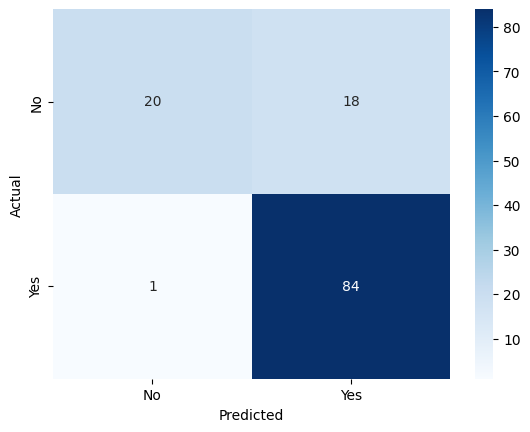

In [7]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

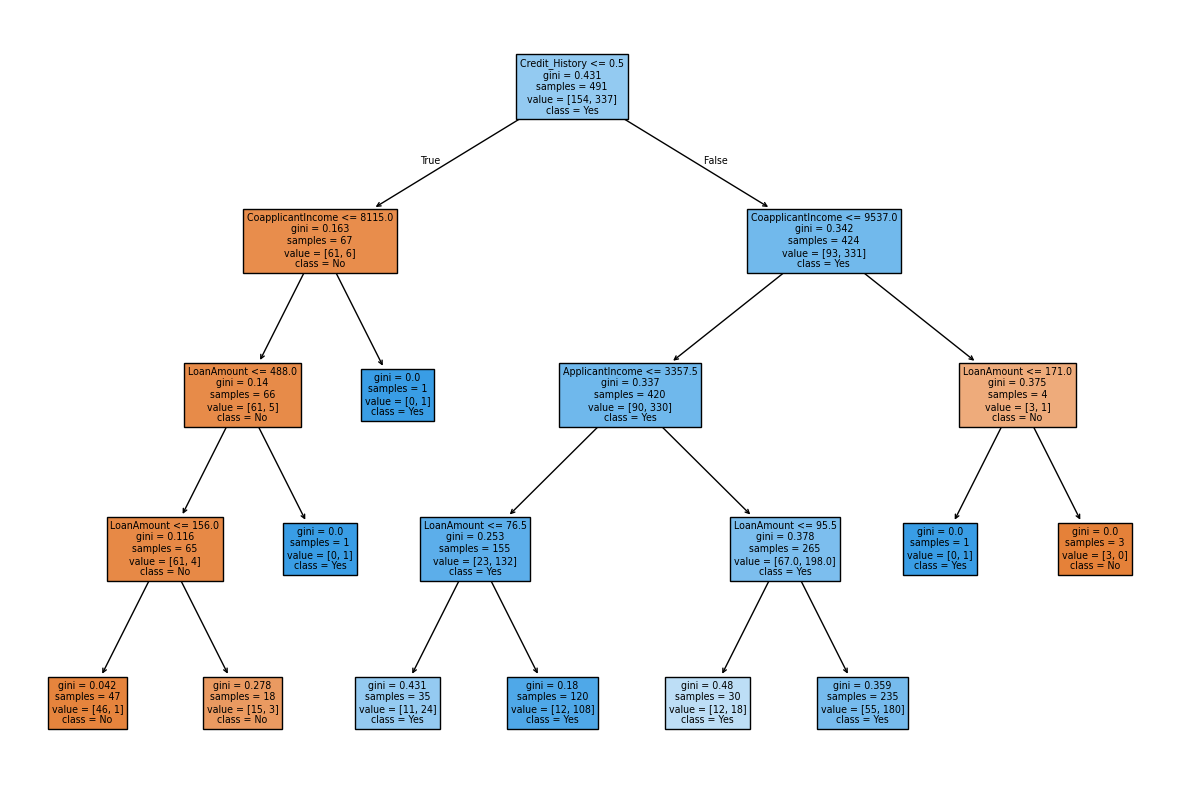

In [8]:
plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

In [9]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)


                    Feature  Importance
4            Credit_History    0.799855
2                LoanAmount    0.111998
1         CoapplicantIncome    0.057269
0           ApplicantIncome    0.030878
3          Loan_Amount_Term    0.000000
5               Gender_Male    0.000000
6               Married_Yes    0.000000
7              Dependents_1    0.000000
8              Dependents_2    0.000000
9             Dependents_3+    0.000000
10   Education_Not Graduate    0.000000
11        Self_Employed_Yes    0.000000
12  Property_Area_Semiurban    0.000000
13      Property_Area_Urban    0.000000


In [10]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=6, random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n🌲 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



🌲 Random Forest Results
Accuracy: 0.8536585365853658
              precision    recall  f1-score   support

       False       0.95      0.55      0.70        38
        True       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [11]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ]
})
print(results)

           Model  Accuracy
0  Decision Tree  0.845528
1  Random Forest  0.853659
